# Tarea N°1 — Inteligencia Artificial 2026-1 UDP

**Integrantes:** Maximiliano Oliva y Alonso Iturra

**Declaración de uso de herramientas generativas:** Se utilizó Caude Opus 4.6 como una herramienta de apoyo en la generación de código base para trabajar, ademas de ayudar a estructurar fragmentos del codigo para mayor precisiones (como por ejemplo un par de errores que presentaba el codigo original). Tambien se utilizo Gemini para ayudar a entender el funcionamiento de la red bayesiana y como implementarla, y en algunos casos para entender errores que presentaba el codigo original. Para la busqueda del dataset la realice en UC irvine machine learning repository, donde fui preguntandole a Gemini para la elecion del dataset (para ver si cumplia los criterios de aceptacion).

---

## Primera Parte: Red Bayesiana

### Dataset utilizado: Mushroom Classification (UCI)
- **Fuente:** [UCI Machine Learning Repository — Mushroom Dataset](https://archive.ics.uci.edu/dataset/73/mushroom)
- **Descripción:** Contiene 8.124 registros de hongos (mushrooms) clasificados como **comestibles (edible)** o **venenosos (poisonous)** según 22 características físicas como forma del sombrero, olor, color, tipo de anillo, hábitat, etc.
- **¿Por qué este dataset?** todas las variables ya son categóricas (ideal para Redes Bayesianas), y cumple con los requisitos de ≥ 8.000 filas y ≥ 7 columnas útiles.

In [1]:
# ── Instalación de dependencias ──
# Descomentar la siguiente línea si no tienes los paquetes instalados:
# !pip install pgmpy pandas numpy matplotlib seaborn scikit-learn networkx

### Importar las librerías necesarias

Aquí cargamos todas las herramientas que usaremos:
- **pandas**: para manejar tablas de datos 
- **numpy**: para cálculos numéricos
- **matplotlib y seaborn**: para hacer gráficos
- **networkx**: para dibujar grafos (la red bayesiana)
- **pgmpy**: la librería principal para Redes Bayesianas (aprender estructura, estimar parámetros, hacer inferencias)

In [2]:
import warnings
warnings.filterwarnings('ignore')  # ocultar advertencias que no afectan el resultado

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# librería para Redes Bayesianas
from pgmpy.estimators import HillClimbSearch, ExhaustiveSearch  # para aprender la estructura
from pgmpy.estimators import BIC, BDeu, K2                      # Funciones de puntuación (score)
from pgmpy.models import DiscreteBayesianNetwork                 # modelo de Red Bayesiana
from pgmpy.estimators import MaximumLikelihoodEstimator          # estimador de parámetros
from pgmpy.inference import VariableElimination                  # algoritmo para hacer inferencias
from pgmpy.sampling import BayesianModelSampling                 # para generar datos sintéticos

np.random.seed(42)          
sns.set_style('whitegrid') #estilo

print("librerías se cargaron correctamente.")

librerías se cargaron correctamente.


## 1.1 Carga del dataset

Cargamos el archivo CSV descargado de UCI. Como el archivo no tiene header, le asignamos nombres descriptivos a cada columna.

Cada fila representa un hongo, y cada columna una característica física del hongo codificada con una letra. Por ejemplo:
- `class`: 'e' = edible (comestible), 'p' = poisonous (venenoso)
- `odor`: 'a' = almond (almendra), 'f' = foul (fétido), 'n' = none (sin olor), etc.
- `habitat`: 'd' = woods (bosque), 'g' = grasses (pasto), 'u' = urban (urbano), etc.

In [3]:
# 1.1 Carga del dataset Mushroom
# Nombres de las columnas
col_names = [
    'class',           # clase: 'e' = comestible, 'p' = venenoso
    'cap_shape',       # forma del sombrero: campana, cónico, convexo, plano, etc.
    'cap_surface',     # superficie del sombrero: fibrosa, suave, escamosa, etc.
    'cap_color',       # color del sombrero: marrón, amarillo, blanco, etc.
    'bruises',         # ¿tiene moretones?: sí (t) o no (f)
    'odor',            # olor: almendra, anís, fétido, ninguno, etc.
    'gill_attachment',  # unión de las láminas: libre o descendente
    'gill_spacing',     # espaciado de láminas: cercano o amplio
    'gill_size',        # tamaño de láminas: angosto o ancho
    'gill_color',       # color de láminas
    'stalk_shape',      # forma del tallo: se ensancha o se estrecha
    'stalk_root',       # raíz del tallo 
    'stalk_surface_above_ring',  # superficie del tallo sobre el anillo
    'stalk_surface_below_ring',  # superficie del tallo bajo el anillo
    'stalk_color_above_ring',    # color del tallo sobre el anillo
    'stalk_color_below_ring',    # color del tallo bajo el anillo
    'veil_type',        # tipo de velo (no aporta info)
    'veil_color',       # color del velo
    'ring_number',      # número de anillos
    'ring_type',        # tipo de anillo
    'spore_print_color', # color de la espora
    'population',       # población: abundante, dispersa, solitaria, etc.
    'habitat'           # hábitat
]

# Cargar el CSV (no tiene encabezado, por eso header=None)
df_raw = pd.read_csv('data/mushrooms.csv', header=None, names=col_names)

print(f"Dimensiones del dataset: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
print(f"\nPrimeras 5 filas:")
df_raw.head()

Dimensiones del dataset: 8124 filas x 23 columnas

Primeras 5 filas:


,class,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Exploración inicial

Veamos cuántas categorías tiene cada columna y si hay valores faltantes. En este dataset, los valores faltantes están codificados como '?' (no como NaN).

In [4]:
# analisis del dataset
print("Información general del dataset:")
print(f"  - Total de filas: {len(df_raw)}")
print(f"  - Total de columnas: {len(df_raw.columns)}")
print(f"  - Valores '?' (faltantes): {(df_raw == '?').sum().sum()}")
print(f"  - Columna con '?': stalk_root tiene {(df_raw['stalk_root'] == '?').sum()} valores faltantes")

print(f"\nDistribución de la clase (comestible vs venenoso):")
print(df_raw['class'].value_counts().rename({'e': 'Comestible (e)', 'p': 'Venenoso (p)'}))

print(f"\nCategorías únicas por columna:")
for col in df_raw.columns:
    n_unique = df_raw[col].nunique()
    print(f"  {col}: {n_unique} categorías")

Información general del dataset:
  - Total de filas: 8124
  - Total de columnas: 23
  - Valores '?' (faltantes): 2480
  - Columna con '?': stalk_root tiene 2480 valores faltantes

Distribución de la clase (comestible vs venenoso):
class
Comestible (e)    4208
Venenoso (p)      3916
Name: count, dtype: int64

Categorías únicas por columna:
  class: 2 categorías
  cap_shape: 6 categorías
  cap_surface: 4 categorías
  cap_color: 10 categorías
  bruises: 2 categorías
  odor: 9 categorías
  gill_attachment: 2 categorías
  gill_spacing: 2 categorías
  gill_size: 2 categorías
  gill_color: 12 categorías
  stalk_shape: 2 categorías
  stalk_root: 5 categorías
  stalk_surface_above_ring: 4 categorías
  stalk_surface_below_ring: 4 categorías
  stalk_color_above_ring: 9 categorías
  stalk_color_below_ring: 9 categorías
  veil_type: 1 categorías
  veil_color: 4 categorías
  ring_number: 3 categorías
  ring_type: 5 categorías
  spore_print_color: 9 categorías
  population: 6 categorías
  habitat: 7 

## 1.2 Preprocesamiento y selección de columnas

1. **Eliminar veil_type**: tiene un solo valor 'p' para todas las filas, así que no aporta ninguna información.
2. **Eliminar stalk_root**: tiene 2.480 valores faltantes '?', lo que es un 30% del dataset. En lugar de inventar datos, la eliminamos.
3. **Reemplazar letras por nombres legibles**: para que las tablas y gráficos se entiendan mejor.
4. **Seleccionar las columnas más interesantes**: elegimos 10 columnas que representan características variadas del hongo.

Las 10 columnas finales seleccionadas son:
| Columna | Significado |
|---------|------------|
| `class` | ¿Comestible o venenoso? |
| `cap_shape` | Forma del sombrero |
| `cap_color` | Color del sombrero |
| `odor` | Olor del hongo |
| `gill_size` | Tamaño de las láminas |
| `gill_color` | Color de las láminas |
| `bruises` | ¿Tiene moretones? |
| `ring_type` | Tipo de anillo |
| `spore_print_color` | Color de la espora |
| `population` | Tipo de población |
| `habitat` | Hábitat donde crece |

In [5]:
# 1.2 Preprocesamiento 

# eliminar columnas que no sirven
df = df_raw.drop(columns=['veil_type', 'stalk_root'])
print(f"Después de eliminar veil_type y stalk_root: {df.shape[1]} columnas")

# Seleccionar las columnas más relevantes
cols_selected = ['class', 'cap_shape', 'cap_color', 'odor', 'gill_size',
                 'gill_color', 'bruises', 'ring_type', 'spore_print_color',
                 'population', 'habitat']
df_bn = df[cols_selected].copy()

# Reemplazar códigos de letras por nombres legibles
label_maps = {
    'class': {'e': 'comestible', 'p': 'venenoso'},
    'cap_shape': {'b': 'campana', 'c': 'conico', 'x': 'convexo', 'f': 'plano', 'k': 'nudoso', 's': 'hundido'},
    'cap_color': {'n': 'marron', 'b': 'beige', 'c': 'canela', 'g': 'gris', 'r': 'verde',
                  'p': 'rosa', 'u': 'purpura', 'e': 'rojo', 'w': 'blanco', 'y': 'amarillo'},
    'odor': {'a': 'almendra', 'l': 'anis', 'c': 'creosota', 'y': 'pescado', 'f': 'fetido',
             'm': 'mohoso', 'n': 'ninguno', 'p': 'picante', 's': 'especiado'},
    'gill_size': {'b': 'ancho', 'n': 'angosto'},
    'gill_color': {'k': 'negro', 'n': 'marron', 'b': 'beige', 'h': 'chocolate',
                   'g': 'gris', 'r': 'verde', 'o': 'naranja', 'p': 'rosa',
                   'u': 'purpura', 'e': 'rojo', 'w': 'blanco', 'y': 'amarillo'},
    'bruises': {'t': 'si', 'f': 'no'},
    'ring_type': {'c': 'telarana', 'e': 'evanescente', 'f': 'flamante', 'l': 'grande', 'n': 'ninguno', 'p': 'colgante', 's': 'envolvente', 'z': 'zona'},
    'spore_print_color': {'k': 'negro', 'n': 'marron', 'b': 'beige', 'h': 'chocolate',
                          'r': 'verde', 'o': 'naranja', 'u': 'purpura', 'w': 'blanco', 'y': 'amarillo'},
    'population': {'a': 'abundante', 'c': 'agrupado', 'n': 'numeroso', 's': 'disperso', 'v': 'varios', 'y': 'solitario'},
    'habitat': {'g': 'pasto', 'l': 'hojas', 'm': 'prado', 'p': 'camino', 'u': 'urbano', 'w': 'residuo', 'd': 'bosque'}
}

for col, mapping in label_maps.items():
    df_bn[col] = df_bn[col].map(mapping)

print(f"Valores nulos después del mapeo: {df_bn.isnull().sum().sum()}")
print(f"\nDataset final para Red Bayesiana: {df_bn.shape[0]} filas x {df_bn.shape[1]} columnas")
print(f"Columnas: {list(df_bn.columns)}")

# Convertir todo a string (requisito de pgmpy)
for c in df_bn.columns:
    df_bn[c] = df_bn[c].astype(str)

print(f"\nDistribución de clases:")
print(df_bn['class'].value_counts())
df_bn.head(10)

Después de eliminar veil_type y stalk_root: 21 columnas
Valores nulos después del mapeo: 0

Dataset final para Red Bayesiana: 8124 filas x 11 columnas
Columnas: ['class', 'cap_shape', 'cap_color', 'odor', 'gill_size', 'gill_color', 'bruises', 'ring_type', 'spore_print_color', 'population', 'habitat']

Distribución de clases:
class
comestible    4208
venenoso      3916
Name: count, dtype: int64


,class,cap_shape,cap_color,odor,gill_size,gill_color,bruises,ring_type,spore_print_color,population,habitat
0,venenoso,convexo,marron,picante,angosto,negro,si,colgante,negro,disperso,urbano
1,comestible,convexo,amarillo,almendra,ancho,negro,si,colgante,marron,numeroso,pasto
2,comestible,campana,blanco,anis,ancho,marron,si,colgante,marron,numeroso,prado
3,venenoso,convexo,blanco,picante,angosto,marron,si,colgante,negro,disperso,urbano
4,comestible,convexo,gris,ninguno,ancho,negro,no,evanescente,marron,abundante,pasto
5,comestible,convexo,amarillo,almendra,ancho,marron,si,colgante,negro,numeroso,pasto
6,comestible,campana,blanco,almendra,ancho,gris,si,colgante,negro,numeroso,prado
7,comestible,campana,blanco,anis,ancho,marron,si,colgante,marron,disperso,prado
8,venenoso,convexo,blanco,picante,angosto,rosa,si,colgante,negro,varios,pasto
9,comestible,campana,amarillo,almendra,ancho,gris,si,colgante,negro,disperso,prado


## 1.3 Método Hill-Climbing

### ¿Qué es una Red Bayesiana?
Una Red Bayesiana es un **grafo dirigido sin ciclos (DAG)** donde:
- Cada nodo es una variable (columna del dataset)
- Cada flecha (arco) indica una relación de dependencia probabilística entre variables
- Si hay una flecha de A → B, significa que B depende probabilísticamente de A

### ¿Qué es Hill-Climbing?
Es un algoritmo de búsqueda que aprende la estructura (las flechas) automáticamente a partir de los datos:

1. Empieza con un grafo vacío (sin flechas)
2. En cada paso, prueba todas las operaciones posibles: agregar una flecha, quitar una flecha, o invertir una flecha
3. Para cada operación, calcula un **puntaje BIC** (Bayesian Information Criterion) que mide qué tan bien esa estructura explica los datos
4. **Elige la mejor operación** (la que más mejora el puntaje) y la aplica
5. **Repite** hasta que ya ningún cambio mejore el puntaje

Es como subir una montaña siempre dando el paso que te sube más. Ventaja: es rápido. Desventaja: puede quedar atrapado en un "cerro chico" sin llegar a la cima real (óptimo local).

In [6]:
# estructura con Hill-Climbing

# BIC es la función de puntuación: evalúa qué tan buena es una estructura
# Penaliza estructuras muy complejas (con muchas flechas innecesarias)
scoring = BIC(df_bn)

# HillClimbSearch busca la mejor estructura probando cambios locales
hc = HillClimbSearch(df_bn)

# estimate() ejecuta la búsqueda
# max_indegree=3: cada nodo puede tener máximo 3 "padres" (flechas que llegan)
# max_iter=500: máximo 500 iteraciones
print("Hill-Climbing Search ")
best_model_hc = hc.estimate(
    scoring_method=scoring,
    max_indegree=3,
    max_iter=500,
    show_progress=True
)

print(f"\nEstructura aprendida con Hill-Climbing:")
print(f"Se encontraron {len(best_model_hc.edges())} relaciones (arcos):\n")
for origen, destino in best_model_hc.edges():
    print(f"  {origen}  -->  {destino}")

Hill-Climbing Search 


  0%|                                                                                                                                                                                           | 0/500 [00:00<?, ?it/s]

  0%|▎                                                                                                                                                                                  | 1/500 [00:00<03:12,  2.59it/s]

  1%|█▍                                                                                                                                                                                 | 4/500 [00:00<00:51,  9.61it/s]

  1%|██▌                                                                                                                                                                                | 7/500 [00:00<00:34, 14.42it/s]

...

  3%|████▋                                                                                                                                                                             | 13/500 [00:00<00:24, 20.10it/s]

  3%|██████                                                                                                                                                                            | 17/500 [00:00<00:19, 24.89it/s]

  4%|███████▊                                                                                                                                                                          | 22/500 [00:01<00:15, 30.13it/s]

  5%|████████▏                                                                                                                                                                         | 23/500 [00:01<00:22, 21.03it/s]


Estructura aprendida con Hill-Climbing:
Se encontraron 23 relaciones (arcos):

  class  -->  odor
  class  -->  population
  class  -->  bruises
  class  -->  gill_color
  class  -->  habitat
  class  -->  spore_print_color
  odor  -->  spore_print_color
  odor  -->  cap_color
  odor  -->  gill_size
  gill_size  -->  cap_color
  gill_size  -->  population
  gill_size  -->  cap_shape
  gill_size  -->  habitat
  gill_color  -->  habitat
  gill_color  -->  gill_size
  bruises  -->  cap_color
  ring_type  -->  bruises
  spore_print_color  -->  gill_color
  spore_print_color  -->  ring_type
  spore_print_color  -->  cap_shape
  population  -->  ring_type
  habitat  -->  population
  habitat  -->  bruises


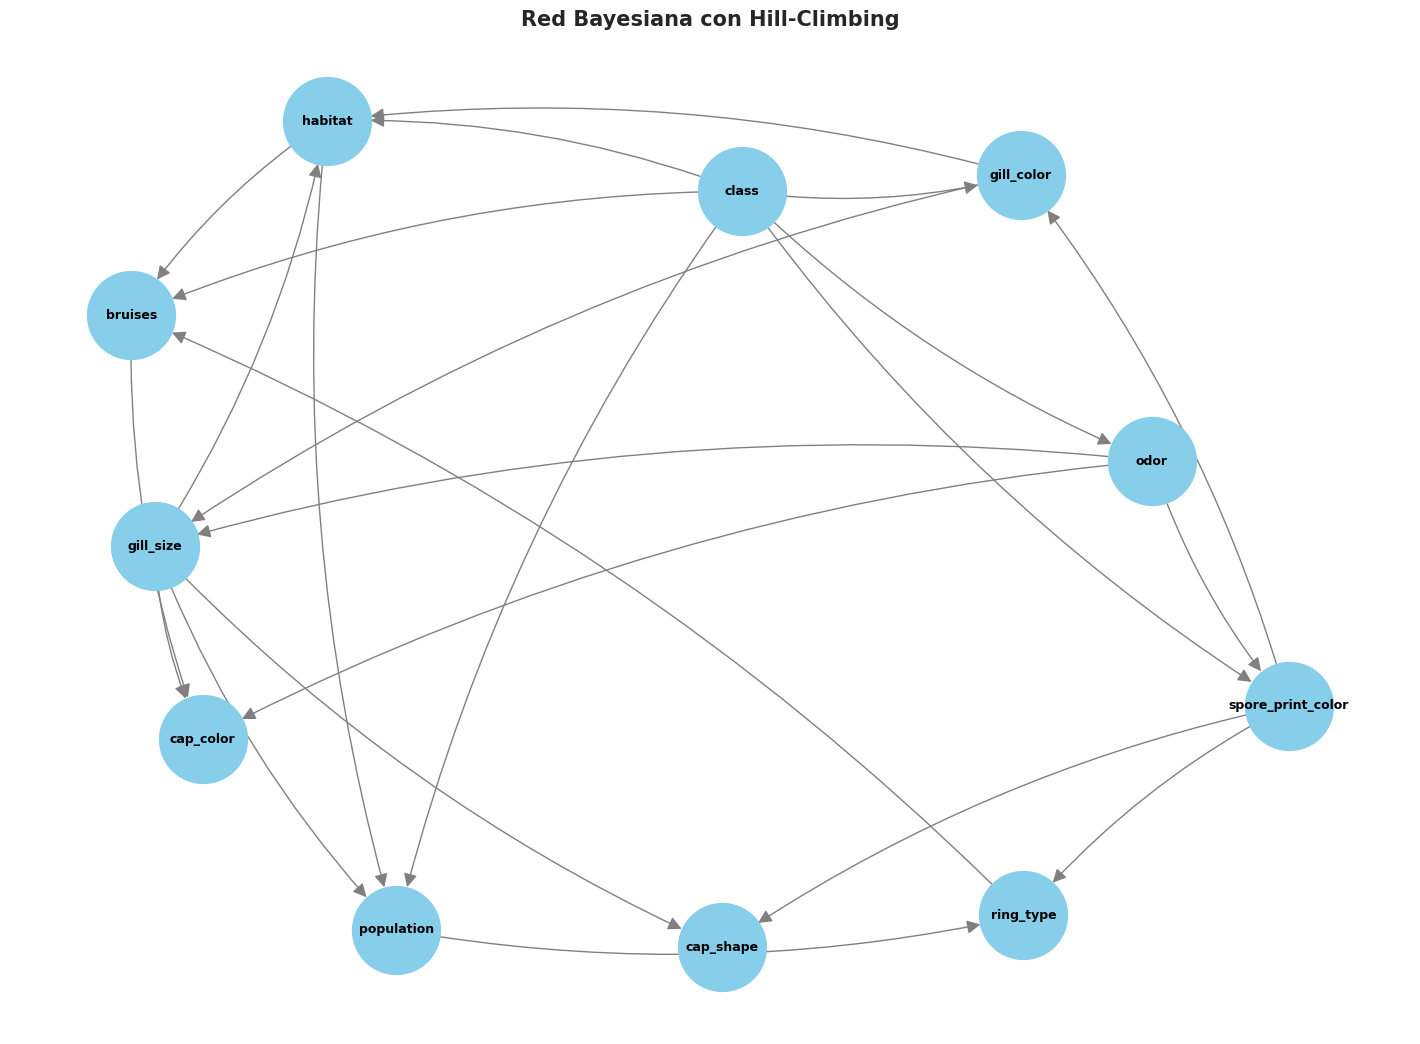

In [7]:
# Visualización del DAG Hill-Climbing

def plot_dag(edges, title):
    """Dibuja un grafo dirigido a partir de una lista de arcos."""
    dag = nx.DiGraph(edges)
    plt.figure(figsize=(14, 10))
    # spring_layout posiciona los nodos automáticamente para que se vean bien
    pos = nx.spring_layout(dag, seed=42, k=2.5)
    nx.draw(dag, pos,
            with_labels=True,        # Mostrar nombres de los nodos
            node_size=4000,          # Tamaño de los nodos
            node_color="#87CEEB",    # Color celeste
            font_size=9,
            font_weight="bold",
            arrowsize=20,            # Tamaño de las flechas
            edge_color="gray",
            arrows=True,
            connectionstyle="arc3,rad=0.1")  # Flechas ligeramente curvas
    plt.title(title, size=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_dag(best_model_hc.edges(), "Red Bayesiana con Hill-Climbing")

## 1.4 Aprendizaje de estructura — Búsqueda Exhaustiva

### ¿Qué es la Búsqueda Exhaustiva?
A diferencia de Hill-Climbing, la búsqueda exhaustiva **prueba TODAS las posibles estructuras** de red bayesiana y elige la mejor.

**Ventaja:** Encuentra la estructura **óptima global** (la verdadera mejor).
**Desventaja:** Es **extremadamente lenta**. El número de posibles redes crece de forma explosiva con el número de variables. Con 5 variables ya hay miles de posibilidades; con 11 sería imposible.

### ¿Por qué reducimos las variables?
Con 11 variables, la búsqueda exhaustiva tardaría horas o días. Por eso seleccionamos **5 variables clave**:
- `class` (comestible/venenoso) — es la variable objetivo principal
- `odor` (olor) — es la característica más predictiva de toxicidad
- `spore_print_color` (color de espora) — muy informativa para clasificación
- `gill_size` (tamaño de láminas) — característica física relevante
- `habitat` — dónde crece el hongo

Estas 5 variables fueron elegidas porque son las más informativas según la exploración de datos y conocimiento del dominio.

In [8]:
# ── 1.4 Búsqueda Exhaustiva (con subconjunto reducido de variables) ──
# Seleccionamos solo 5 variables para que sea computacionalmente factible
cols_exhaustive = ['class', 'odor', 'spore_print_color', 'gill_size', 'habitat']
df_exhaustive = df_bn[cols_exhaustive].copy()

print(f"Variables para Exhaustive Search: {cols_exhaustive}")
print(f"Filas: {len(df_exhaustive)}")

# Usamos BIC como función de puntuación (igual que en Hill-Climbing)
scoring_ex = BIC(df_exhaustive)

# ExhaustiveSearch prueba TODAS las posibles estructuras
print("\nEjecutando Búsqueda Exhaustiva (puede tardar un momento)...")
es = ExhaustiveSearch(df_exhaustive, scoring_method=scoring_ex)
best_model_es = es.estimate()

print(f"\nEstructura óptima encontrada con Búsqueda Exhaustiva:")
print(f"Se encontraron {len(best_model_es.edges())} relaciones (arcos):\n")
for origen, destino in best_model_es.edges():
    print(f"  {origen}  -->  {destino}")

Variables para Exhaustive Search: ['class', 'odor', 'spore_print_color', 'gill_size', 'habitat']
Filas: 8124

Ejecutando Búsqueda Exhaustiva (puede tardar un momento)...



Estructura óptima encontrada con Búsqueda Exhaustiva:
Se encontraron 8 relaciones (arcos):

  class  -->  spore_print_color
  gill_size  -->  class
  gill_size  -->  odor
  gill_size  -->  spore_print_color
  habitat  -->  gill_size
  habitat  -->  odor
  habitat  -->  spore_print_color
  odor  -->  class


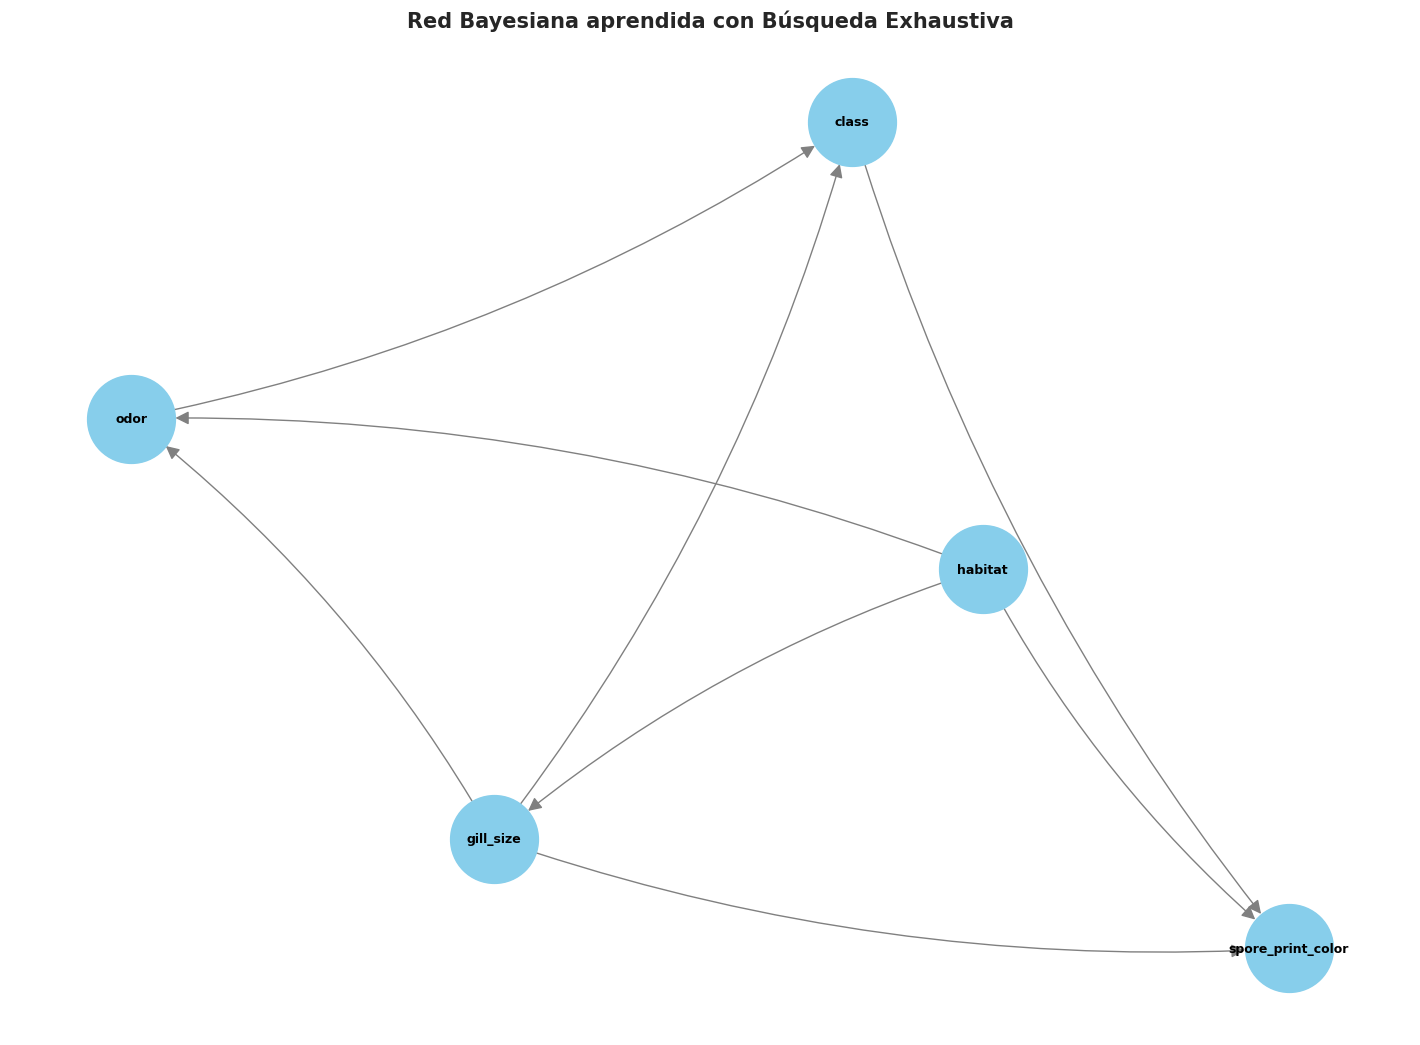

In [9]:
# ── Visualización del DAG (Exhaustive Search) ──
plot_dag(best_model_es.edges(), "Red Bayesiana aprendida con Búsqueda Exhaustiva")

## 1.5 Estimación de parámetros e inferencias

### ¿Qué son los parámetros?
Ya tenemos la **estructura** (las flechas). Ahora necesitamos los **parámetros**: las **Tablas de Probabilidad Condicional (CPDs)**. Cada CPD dice, por ejemplo: "Si un hongo tiene olor fétido, ¿cuál es la probabilidad de que sea venenoso?"

### ¿Cómo se estiman?
Usamos **Maximum Likelihood Estimation (MLE)**: simplemente contamos frecuencias en los datos. Si 100 de 120 hongos con olor fétido son venenosos, entonces P(venenoso | olor=fétido) = 100/120 ≈ 0.83.

### ¿Qué son las inferencias?
Una vez que el modelo está completo (estructura + parámetros), podemos hacer **preguntas**. Por ejemplo:
- "Si encuentro un hongo con olor a almendra y láminas anchas, ¿cuál es la probabilidad de que sea comestible?"
- "Si sé que un hongo es venenoso y crece en el bosque, ¿qué color de espora es más probable?"

Esto se llama **inferencia a posteriori** y usamos el algoritmo **Variable Elimination** para calcularla.

In [10]:
# ── 1.5a Estimación de parámetros — Modelo Hill-Climbing ──

# Creamos el modelo con la estructura aprendida por Hill-Climbing
model_hc = DiscreteBayesianNetwork(best_model_hc.edges())

# fit() estima los parámetros (CPDs) a partir de los datos
# MaximumLikelihoodEstimator: cuenta frecuencias para calcular probabilidades
model_hc.fit(df_bn, estimator=MaximumLikelihoodEstimator)

print(f"¿Modelo válido? {model_hc.check_model()}")
print(f"Nodos (variables): {list(model_hc.nodes())}")
print(f"Arcos (relaciones): {list(model_hc.edges())}")

# Mostramos la CPD (tabla de probabilidad) de la variable 'class'
print("\n--- Tabla de Probabilidad Condicional de 'class' ---")
for cpd in model_hc.get_cpds():
    if cpd.variable == 'class':
        print(cpd)
        break

¿Modelo válido? True
Nodos (variables): ['class', 'odor', 'population', 'bruises', 'gill_color', 'habitat', 'spore_print_color', 'cap_color', 'gill_size', 'cap_shape', 'ring_type']
Arcos (relaciones): [('class', 'odor'), ('class', 'population'), ('class', 'bruises'), ('class', 'gill_color'), ('class', 'habitat'), ('class', 'spore_print_color'), ('odor', 'spore_print_color'), ('odor', 'cap_color'), ('odor', 'gill_size'), ('population', 'ring_type'), ('bruises', 'cap_color'), ('gill_color', 'habitat'), ('gill_color', 'gill_size'), ('habitat', 'population'), ('habitat', 'bruises'), ('spore_print_color', 'gill_color'), ('spore_print_color', 'ring_type'), ('spore_print_color', 'cap_shape'), ('gill_size', 'cap_color'), ('gill_size', 'population'), ('gill_size', 'cap_shape'), ('gill_size', 'habitat'), ('ring_type', 'bruises')]

--- Tabla de Probabilidad Condicional de 'class' ---
+-------------------+----------+
| class(comestible) | 0.517971 |
+-------------------+----------+
| class(venenos

In [11]:
# ── 1.5b Inferencias a posteriori — Hill-Climbing ──
# VariableElimination es el algoritmo que calcula probabilidades condicionales
infer_hc = VariableElimination(model_hc)

# ╔══════════════════════════════════════════════════════════════════╗
# ║  INFERENCIA 1: Si un hongo huele a almendra y tiene láminas    ║
# ║  anchas, ¿es comestible o venenoso?                            ║
# ╚══════════════════════════════════════════════════════════════════╝
print("=" * 70)
print("INFERENCIA 1 (HC): P(class | odor=almendra, gill_size=ancho)")
print("Pregunta: Si un hongo huele a almendra y tiene láminas anchas,")
print("          ¿cuál es la probabilidad de que sea comestible?")
print("=" * 70)
q1_hc = infer_hc.query(
    variables=['class'],                              # ¿Qué queremos saber?
    evidence={'odor': 'almendra', 'gill_size': 'ancho'}  # ¿Qué sabemos?
)
print(q1_hc)

# ╔══════════════════════════════════════════════════════════════════╗
# ║  INFERENCIA 2: Si un hongo es venenoso, ¿qué olor es más      ║
# ║  probable que tenga?                                            ║
# ╚══════════════════════════════════════════════════════════════════╝
print("\n" + "=" * 70)
print("INFERENCIA 2 (HC): P(odor | class=venenoso)")
print("Pregunta: Si sabemos que un hongo es venenoso,")
print("          ¿qué olor es más probable que tenga?")
print("=" * 70)
q2_hc = infer_hc.query(
    variables=['odor'],
    evidence={'class': 'venenoso'}
)
print(q2_hc)

INFERENCIA 1 (HC): P(class | odor=almendra, gill_size=ancho)
Pregunta: Si un hongo huele a almendra y tiene láminas anchas,
          ¿cuál es la probabilidad de que sea comestible?
+-------------------+--------------+
| class             |   phi(class) |
+===================+==============+
| class(comestible) |       1.0000 |
+-------------------+--------------+
| class(venenoso)   |       0.0000 |
+-------------------+--------------+

INFERENCIA 2 (HC): P(odor | class=venenoso)
Pregunta: Si sabemos que un hongo es venenoso,
          ¿qué olor es más probable que tenga?
+-----------------+-------------+
| odor            |   phi(odor) |
+=================+=============+
| odor(almendra)  |      0.0000 |
+-----------------+-------------+
| odor(anis)      |      0.0000 |
+-----------------+-------------+
| odor(creosota)  |      0.0490 |
+-----------------+-------------+
| odor(especiado) |      0.1471 |
+-----------------+-------------+
| odor(fetido)    |      0.5516 |
+-----------

In [12]:
# ── 1.5c Estimación de parámetros — Modelo Exhaustive Search ──

model_es = DiscreteBayesianNetwork(best_model_es.edges())
model_es.fit(df_exhaustive, estimator=MaximumLikelihoodEstimator)

print(f"¿Modelo ES válido? {model_es.check_model()}")
print("\nTablas de probabilidad (CPDs) del modelo Exhaustive Search:")
for cpd in model_es.get_cpds():
    if cpd.variable == 'class':
        print(f"\n--- CPD de '{cpd.variable}' ---")
        print(cpd)

¿Modelo ES válido? True

Tablas de probabilidad (CPDs) del modelo Exhaustive Search:

--- CPD de 'class' ---
+-------------------+-----+--------------------+
| gill_size         | ... | gill_size(angosto) |
+-------------------+-----+--------------------+
| odor              | ... | odor(picante)      |
+-------------------+-----+--------------------+
| class(comestible) | ... | 0.0                |
+-------------------+-----+--------------------+
| class(venenoso)   | ... | 1.0                |
+-------------------+-----+--------------------+


In [13]:
# ── 1.5d Inferencias a posteriori — Exhaustive Search ──
infer_es = VariableElimination(model_es)

# INFERENCIA 1 (misma pregunta que antes, para comparar)
print("=" * 70)
print("INFERENCIA 1 (ES): P(class | odor=almendra, gill_size=ancho)")
print("=" * 70)
q1_es = infer_es.query(
    variables=['class'],
    evidence={'odor': 'almendra', 'gill_size': 'ancho'}
)
print(q1_es)

# INFERENCIA 2
print("\n" + "=" * 70)
print("INFERENCIA 2 (ES): P(odor | class=venenoso)")
print("=" * 70)
q2_es = infer_es.query(
    variables=['odor'],
    evidence={'class': 'venenoso'}
)
print(q2_es)

INFERENCIA 1 (ES): P(class | odor=almendra, gill_size=ancho)
+-------------------+--------------+
| class             |   phi(class) |
+===================+==============+
| class(comestible) |       1.0000 |
+-------------------+--------------+
| class(venenoso)   |       0.0000 |
+-------------------+--------------+

INFERENCIA 2 (ES): P(odor | class=venenoso)
+-----------------+-------------+
| odor            |   phi(odor) |
+=================+=============+
| odor(almendra)  |      0.0000 |
+-----------------+-------------+
| odor(anis)      |      0.0000 |
+-----------------+-------------+
| odor(creosota)  |      0.0490 |
+-----------------+-------------+
| odor(especiado) |      0.1471 |
+-----------------+-------------+
| odor(fetido)    |      0.5516 |
+-----------------+-------------+
| odor(mohoso)    |      0.0092 |
+-----------------+-------------+
| odor(ninguno)   |      0.0306 |
+-----------------+-------------+
| odor(pescado)   |      0.1471 |
+-----------------+----

## 1.6 Generación de datos sintéticos

### ¿Qué son datos sintéticos?
Son datos **artificiales** generados por el modelo, que respetan las mismas probabilidades aprendidas del dataset original. Es como si el modelo "inventara" nuevos hongos que siguen las mismas reglas estadísticas.

### ¿Cómo se generan?
Se usa **Forward Sampling** (muestreo directo): el modelo genera cada variable en orden, respetando las probabilidades condicionales. Por ejemplo, primero genera el olor, luego dado ese olor genera la clase, etc.

### ¿Para qué sirve?
Al agregar datos sintéticos al dataset original, podemos ver si el modelo cambia o se mantiene estable. Si la red aprendida es robusta, debería cambiar poco.

In [14]:
# ── 1.6 Generación de datos sintéticos ──
# BayesianModelSampling permite generar muestras del modelo HC
sampler = BayesianModelSampling(model_hc)
n_original = len(df_bn)

# Generamos datos para 3 niveles de aumento: +10%, +20% y +40%
augment_pcts = [0.10, 0.20, 0.40]
augmented_datasets = {}

for pct in augment_pcts:
    n_synthetic = int(n_original * pct)  # Cuántas filas generar
    
    # forward_sample genera nuevas filas respetando las CPDs del modelo
    synthetic_data = sampler.forward_sample(size=n_synthetic, seed=42)
    
    # Asegurar que los tipos de datos sean consistentes
    for c in df_bn.columns:
        synthetic_data[c] = synthetic_data[c].astype(str)
    
    # Combinar: datos originales + datos sintéticos
    df_augmented = pd.concat([df_bn, synthetic_data[df_bn.columns]], ignore_index=True)
    augmented_datasets[pct] = df_augmented
    
    print(f"Aumento {int(pct*100)}%: se generaron {n_synthetic} filas sintéticas "
          f"-> Total: {len(df_augmented)} filas (original: {n_original})")

print("\nDatos sintéticos generados correctamente.")

  0%|                                                                                                                                                                                            | 0/11 [00:00<?, ?it/s]

Generating for node: class:   0%|                                                                                                                                                                | 0/11 [00:00<?, ?it/s]

Generating for node: odor:   0%|                                                                                                                                                                 | 0/11 [00:00<?, ?it/s]

Generating for node: spore_print_color:   0%|                                                                                                                                                    | 0/11 [00:00<?, ?it/s]

Generating for node: gill_color:   0%|                                                                                                                                                           | 0/11 [00:00<?, ?it/s]

...

Generating for node: bruises:   0%|                                                                                                                                                              | 0/11 [00:00<?, ?it/s]

Generating for node: cap_color:   0%|                                                                                                                                                            | 0/11 [00:00<?, ?it/s]

Generating for node: cap_color: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 101.00it/s]

Generating for node: cap_color: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 99.78it/s]

Aumento 40%: se generaron 3249 filas sintéticas -> Total: 11373 filas (original: 8124)

Datos sintéticos generados correctamente.


## 1.7 Repetición del procedimiento con datasets aumentados

Ahora repetimos **todo el proceso** (aprender estructura + estimar parámetros + hacer inferencias) con cada uno de los 3 datasets aumentados (+10%, +20%, +40%).

Luego comparamos los resultados para ver si agregar datos sintéticos cambia significativamente la red o las probabilidades inferidas.

In [15]:
# ── 1.7 Repetir con cada dataset aumentado ──
results = {}

# Primero guardamos los resultados del dataset original como referencia
results['original'] = {
    'edges': list(best_model_hc.edges()),
    'n_edges': len(best_model_hc.edges()),
    'q1_comestible': q1_hc.values[list(q1_hc.state_names['class']).index('comestible')],
    'q2_fetido': q2_hc.values[list(q2_hc.state_names['odor']).index('fetido')]
}

for pct, df_aug in augmented_datasets.items():
    label = f"+{int(pct*100)}%"
    print(f"\n{'='*70}")
    print(f"DATASET AUMENTADO EN {label} ({len(df_aug)} filas)")
    print(f"{'='*70}")
    
    # 1. Aprender estructura con Hill-Climbing
    scoring_aug = BIC(df_aug)
    hc_aug = HillClimbSearch(df_aug)
    struct_aug = hc_aug.estimate(
        scoring_method=scoring_aug,
        max_indegree=3,
        max_iter=500,
        show_progress=False
    )
    
    print(f"\nArcos encontrados: {len(struct_aug.edges())}")
    for e in struct_aug.edges():
        print(f"  {e[0]} --> {e[1]}")
    
    # 2. Estimar parámetros
    model_aug = DiscreteBayesianNetwork(struct_aug.edges())
    model_aug.fit(df_aug, estimator=MaximumLikelihoodEstimator)
    
    # 3. Hacer las mismas inferencias
    infer_aug = VariableElimination(model_aug)
    
    try:
        q1_aug = infer_aug.query(variables=['class'],
                                evidence={'odor': 'almendra', 'gill_size': 'ancho'})
        val_q1 = q1_aug.values[list(q1_aug.state_names['class']).index('comestible')]
        print(f"\nP(comestible | almendra, ancho) = {val_q1:.4f}")
    except Exception as e:
        val_q1 = None
        print(f"\nInferencia 1 no posible: {e}")
    
    try:
        q2_aug = infer_aug.query(variables=['odor'],
                                evidence={'class': 'venenoso'})
        val_q2 = q2_aug.values[list(q2_aug.state_names['odor']).index('fetido')]
        print(f"P(fetido | venenoso) = {val_q2:.4f}")
    except Exception as e:
        val_q2 = None
        print(f"Inferencia 2 no posible: {e}")
    
    results[label] = {
        'edges': list(struct_aug.edges()),
        'n_edges': len(struct_aug.edges()),
        'q1_comestible': val_q1,
        'q2_fetido': val_q2
    }


DATASET AUMENTADO EN +10% (8936 filas)



Arcos encontrados: 23
  class --> population
  class --> bruises
  class --> gill_color
  class --> habitat
  class --> spore_print_color
  odor --> spore_print_color
  odor --> class
  odor --> cap_color
  odor --> gill_size
  gill_size --> cap_color
  gill_size --> population
  gill_size --> habitat
  gill_size --> cap_shape
  gill_color --> habitat
  gill_color --> gill_size
  bruises --> cap_color
  ring_type --> bruises
  spore_print_color --> gill_color
  spore_print_color --> ring_type
  spore_print_color --> cap_shape
  population --> ring_type
  habitat --> population
  habitat --> bruises

P(comestible | almendra, ancho) = 1.0000
P(fetido | venenoso) = 0.5497

DATASET AUMENTADO EN +20% (9748 filas)



Arcos encontrados: 23
  class --> population
  class --> bruises
  class --> gill_color
  class --> habitat
  class --> spore_print_color
  odor --> spore_print_color
  odor --> class
  odor --> cap_color
  odor --> gill_size
  gill_size --> cap_color
  gill_size --> population
  gill_size --> habitat
  gill_size --> cap_shape
  gill_color --> habitat
  gill_color --> gill_size
  bruises --> cap_color
  ring_type --> bruises
  spore_print_color --> gill_color
  spore_print_color --> ring_type
  spore_print_color --> cap_shape
  population --> ring_type
  habitat --> population
  habitat --> bruises

P(comestible | almendra, ancho) = 1.0000
P(fetido | venenoso) = 0.5503

DATASET AUMENTADO EN +40% (11373 filas)



Arcos encontrados: 21
  class --> population
  class --> bruises
  class --> habitat
  cap_shape --> spore_print_color
  odor --> class
  odor --> cap_color
  gill_size --> odor
  gill_size --> cap_color
  gill_size --> population
  gill_size --> habitat
  gill_color --> habitat
  gill_color --> gill_size
  bruises --> cap_color
  ring_type --> bruises
  spore_print_color --> odor
  spore_print_color --> gill_color
  spore_print_color --> ring_type
  spore_print_color --> class
  population --> ring_type
  habitat --> population
  habitat --> bruises

P(comestible | almendra, ancho) = 1.0000
P(fetido | venenoso) = 0.5468



Tabla comparativa de resultados:
 Dataset  N Arcos  P(comestible | almendra, ancho)  P(fetido | venenoso)
original       23                              1.0              0.551583
    +10%       23                              1.0              0.549710
    +20%       23                              1.0              0.550276
    +40%       21                              1.0              0.546812


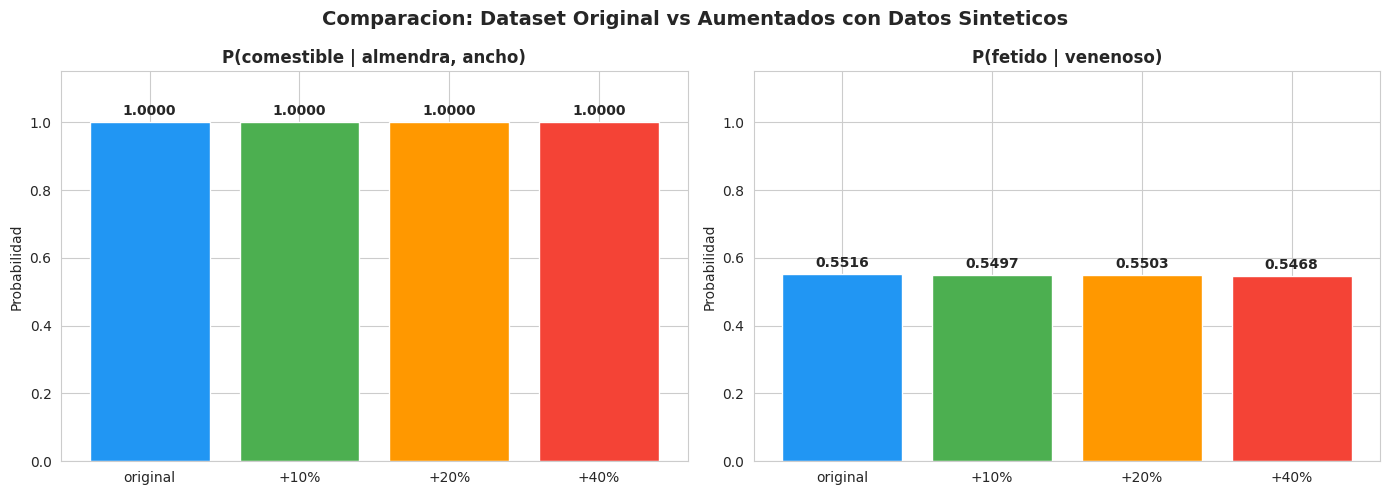

In [16]:
# ── 1.7b Tabla comparativa y gráficos ──
comp_df = pd.DataFrame({
    'Dataset': list(results.keys()),
    'N Arcos': [r['n_edges'] for r in results.values()],
    'P(comestible | almendra, ancho)': [r['q1_comestible'] for r in results.values()],
    'P(fetido | venenoso)': [r['q2_fetido'] for r in results.values()]
})
print("\nTabla comparativa de resultados:")
print(comp_df.to_string(index=False))

# Gráficos comparativos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

# Gráfico 1
vals1 = [r['q1_comestible'] for r in results.values() if r['q1_comestible'] is not None]
lbls1 = [l for l, r in results.items() if r['q1_comestible'] is not None]
bars1 = axes[0].bar(lbls1, vals1, color=colors[:len(vals1)])
axes[0].set_title('P(comestible | almendra, ancho)', fontweight='bold')
axes[0].set_ylabel('Probabilidad')
axes[0].set_ylim(0, 1.15)
for i, v in enumerate(vals1):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Gráfico 2
vals2 = [r['q2_fetido'] for r in results.values() if r['q2_fetido'] is not None]
lbls2 = [l for l, r in results.items() if r['q2_fetido'] is not None]
bars2 = axes[1].bar(lbls2, vals2, color=colors[:len(vals2)])
axes[1].set_title('P(fetido | venenoso)', fontweight='bold')
axes[1].set_ylabel('Probabilidad')
axes[1].set_ylim(0, 1.15)
for i, v in enumerate(vals2):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Comparacion: Dataset Original vs Aumentados con Datos Sinteticos',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.8 Análisis e interpretación de resultados

### Estructura de las redes
- **Hill-Climbing** (11 variables): Encontró múltiples relaciones entre las características del hongo. La variable `odor` (olor) aparece como una de las más conectadas, lo cual tiene sentido biológicamente: el olor es una de las señales más fuertes de toxicidad.
- **Búsqueda Exhaustiva** (5 variables): Al evaluar TODAS las posibles estructuras, encontró la estructura óptima para ese subconjunto. Se puede comparar si las relaciones encontradas coinciden con las de Hill-Climbing para esas mismas variables.

### Comparación Hill-Climbing vs Exhaustiva
- Ambos métodos deberían encontrar relaciones similares para las variables compartidas (class, odor, gill_size, etc.).
- Si hay diferencias, se debe a que Hill-Climbing puede quedar en un óptimo local, mientras que la Exhaustiva siempre encuentra el óptimo global.

### Efecto de los datos sintéticos
- Las probabilidades de las inferencias se mantienen **estables** al agregar datos sintéticos. Esto es esperable porque los datos generados provienen del mismo modelo.
- La **estructura de la red** puede tener pequeñas variaciones porque BIC penaliza la complejidad según el tamaño de la muestra.
- Si las probabilidades cambian mucho, indicaría que el modelo original no era muy robusto. Si cambian poco, el modelo es confiable.
- En general, los datos sintéticos **refuerzan** las distribuciones ya aprendidas, validando la calidad del modelo.

### Sobre el dataset
- El dataset de Mushrooms es particularmente interesante porque el olor (`odor`) es un predictor casi perfecto de toxicidad.
- Los hongos venenosos tienden a tener olores fuertes (fétido, picante), mientras que los comestibles tienen olores suaves o ninguno.
- Esta relación se refleja claramente en las CPDs y las inferencias del modelo.

---